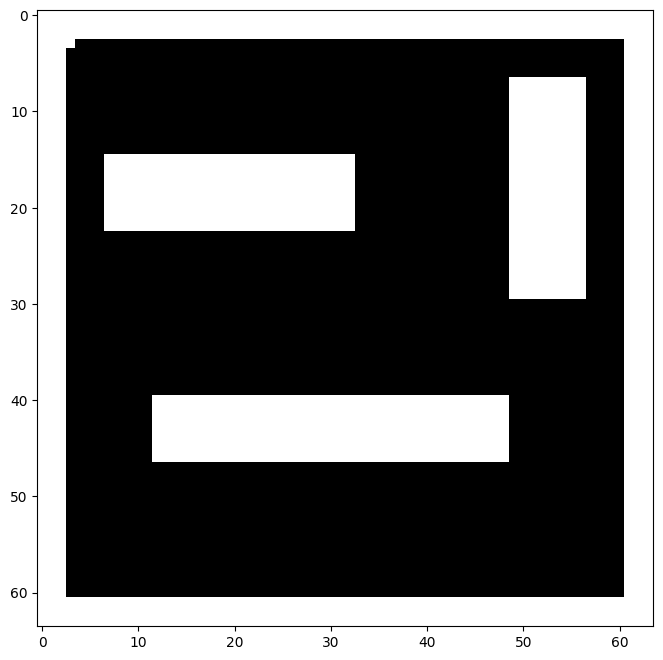

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time

import networkx as nx

from coppeliasim_zmqremoteapi_client import RemoteAPIClient 


def Rz(theta):
  
    return np.array([[ np.cos(theta), -np.sin(theta), 0 ],
                      [ np.sin(theta), np.cos(theta) , 0 ],
                      [ 0            , 0             , 1 ]])

fig = plt.figure(figsize=(8,8), dpi=100)
ax = fig.add_subplot(111, aspect='equal')

# Invertendo os valores para visualização (Branco - 0, Preto - 1)
img = 1 - mpimg.imread('../mapas_meus/teste1_invertido.png')
#img = 1 - mpimg.imread('img/maze.png')

# Apenas para garantir que só teremos esses dois valores
threshold = 0.5
img[img > threshold] = 1
img[img<= threshold] = 0

ax.imshow(img, cmap='Greys', origin='upper')

# Dimensões do mapa informado em metros (X, Y)
map_dims = np.array([64, 64]) # Cave 

# Escala Pixel/Metro
sy, sx = img.shape[:2] / map_dims

# Tamanho da célula do nosso Grid (em metros)
cell_size = 1

rows, cols = (map_dims / cell_size).astype(int)
grid = np.zeros((rows, cols))

# Preenchendo o Grid
# Cada célula recebe o somatório dos valores dos Pixels
for r in range(rows):
    for c in range(cols):
        
        xi = int(c*cell_size*sx)
        xf = int(xi + cell_size*sx)
        
        yi = int(r*cell_size*sy)
        yf = int(yi + cell_size*sy)
                      
        grid[r, c] = np.sum(img[yi:yf,xi:xf])
        
# Binarizando as células como ocupadas (1) ou Não-ocupadas (0)       
grid[grid > threshold] = 1
grid[grid<= threshold] = 0        


✅ RRT: caminho encontrado em iteração 72, tempo 0.00s


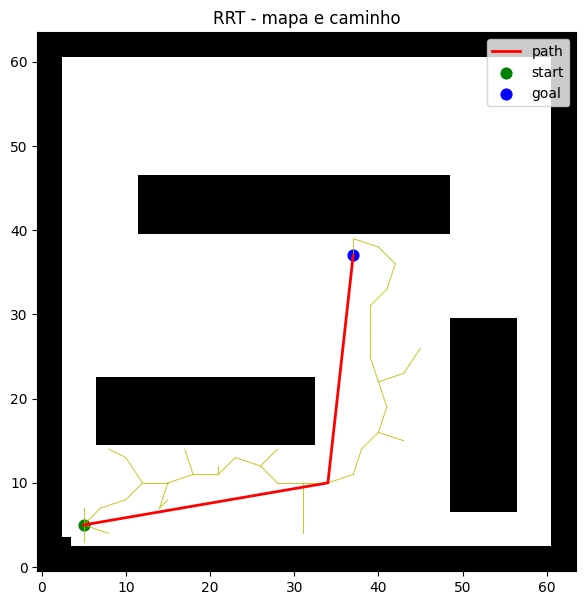

Caminho encontrado com 3 nós.
Start node (px): (5, 5) World: (-4.21875, 4.21875)
Goal node (px): (37, 37) World: (0.78125, -0.78125)
✅ Simulação iniciada; seguindo waypoints...
✅ Waypoint 0 alcançado (3 total).


KeyboardInterrupt: 

In [3]:
"""
RRT planner para grid 64x64.
Entrada:
 - grid: np.array(rows,cols) com 0=livre, 1=ocupado
 - start: (row, col)
 - goal:  (row, col)
Saída:
 - pos: dict {idx: (x_px, y_px)}  (x_px=coluna, y_px=linha)
 - path: list de índices na ordem do caminho
"""

import numpy as np
import matplotlib.pyplot as plt
import random
import math
import time

# se quiser integrar ao CoppeliaSim (opcional)
try:
    from coppeliasim_zmqremoteapi_client import RemoteAPIClient
    COPPELIA_AVAILABLE = True
except Exception:
    COPPELIA_AVAILABLE = False

class Node:
    def __init__(self, coord, parent=None):
        # coord: (row, col)
        self.coord = coord
        self.parent = parent

def dist(a, b):
    return math.hypot(a[0]-b[0], a[1]-b[1])

def sample_free(rows, cols, goal, goal_sample_rate=0.05):
    """
    Amostragem: com probabilidade goal_sample_rate retorna goal (bias),
    caso contrário retorna amostra aleatória no grid.
    """
    if random.random() < goal_sample_rate:
        return goal
    return (random.randint(0, rows-1), random.randint(0, cols-1))

def nearest(nodes, sample):
    """
    Retorna índice do nó mais próximo na lista `nodes` para a amostra `sample`.
    nodes: lista de Node
    sample: (row,col)
    """
    best_idx = 0
    best_d = float('inf')
    for i, n in enumerate(nodes):
        d = dist(n.coord, sample)
        if d < best_d:
            best_d = d
            best_idx = i
    return best_idx

def steer(from_coord, to_coord, step_size):
    """
    Retorna um novo ponto partindo de `from_coord` na direção de `to_coord`
    com distância máxima step_size (em células). Se a distância é menor que
    step_size, retorna to_coord.
    """
    d = dist(from_coord, to_coord)
    if d <= step_size:
        return to_coord
    else:
        theta = math.atan2(to_coord[0]-from_coord[0], to_coord[1]-from_coord[1])  # note: row ~ y
        # deslocamento em row/col: usamos sin/cos adequadamente
        new_r = from_coord[0] + step_size * math.sin(theta)
        new_c = from_coord[1] + step_size * math.cos(theta)
        # arredondar para inteiro de célula mais próximo
        return (int(round(new_r)), int(round(new_c)))

def collision_free(grid, a, b, step=0.5):
    """
    Verifica colisão entre dois pontos a e b (cada um (row,col)).
    Percorre o segmento em passos e verifica se algum ponto cai em célula ocupada.
    step: resolução de amostragem (em células)
    """
    a_r, a_c = a
    b_r, b_c = b
    length = dist(a, b)
    if length == 0:
        # verificar célula
        r, c = int(round(a_r)), int(round(a_c))
        if 0 <= r < grid.shape[0] and 0 <= c < grid.shape[1]:
            return grid[r, c] == 0
        return False
    n_samples = max(int(math.ceil(length / step)), 1)
    for i in range(n_samples+1):
        t = i / n_samples
        r = a_r + (b_r - a_r) * t
        c = a_c + (b_c - a_c) * t
        ri, ci = int(round(r)), int(round(c))
        if not (0 <= ri < grid.shape[0] and 0 <= ci < grid.shape[1]):
            return False
        if grid[ri, ci] == 1:
            return False
    return True

def reconstruct_path(node):
    path = []
    cur = node
    while cur is not None:
        path.append(cur.coord)
        cur = cur.parent
    return path[::-1]

def rrt_planner(grid, start, goal,
                max_iter=10000,
                step_size=3,
                goal_sample_rate=0.05,
                connect_circle_dist=10,
                visualize=True,
                smoothing_iters=100):
    """
    RRT básico (não RRT*). Retorna pos, path_coords (lista de (row,col)) e nodes.
    """
    rows, cols = grid.shape
    if grid[start[0], start[1]] == 1:
        raise RuntimeError("Start dentro de obstáculo")
    if grid[goal[0], goal[1]] == 1:
        raise RuntimeError("Goal dentro de obstáculo")

    nodes = [Node(start, parent=None)]

    found = False
    goal_node = None
    start_time = time.time()

    for it in range(max_iter):
        sample = sample_free(rows, cols, goal, goal_sample_rate=goal_sample_rate)
        nearest_idx = nearest(nodes, sample)
        nearest_node = nodes[nearest_idx]
        new_coord = steer(nearest_node.coord, sample, step_size)

        # checar limites e colisões
        if not (0 <= new_coord[0] < rows and 0 <= new_coord[1] < cols):
            continue
        if grid[new_coord[0], new_coord[1]] == 1:
            continue
        if not collision_free(grid, nearest_node.coord, new_coord, step=0.5):
            continue

        new_node = Node(new_coord, parent=nearest_node)
        nodes.append(new_node)

        # checar se chegamos no goal (dentro de step_size ou colisão-free para goal)
        if dist(new_coord, goal) <= step_size and collision_free(grid, new_coord, goal, step=0.5):
            goal_node = Node(goal, parent=new_node)
            nodes.append(goal_node)
            found = True
            print(f"✅ RRT: caminho encontrado em iteração {it}, tempo {time.time()-start_time:.2f}s")
            break

    if not found:
        print("⚠️ RRT: não encontrou caminho dentro do número máximo de iterações.")
        return None, None, nodes

    # reconstruir caminho
    path_coords = reconstruct_path(goal_node)

    # smoothing (short-cut): tenta juntar pares distantes se colisão-free
    def shortcut(path_coords, iters=smoothing_iters):
        if len(path_coords) <= 2:
            return path_coords
        for _ in range(iters):
            if len(path_coords) <= 2:
                break
            i = random.randint(0, len(path_coords)-2)
            j = random.randint(i+1, len(path_coords)-1)
            if j == i+1:
                continue
            if collision_free(grid, path_coords[i], path_coords[j], step=0.5):
                # remove os pontos entre i e j
                new_path = path_coords[:i+1] + path_coords[j:]
                path_coords = new_path
        return path_coords

    path_coords = shortcut(path_coords, smoothing_iters)

    # converter para pos (dict idx -> (x_px, y_px)) com x_px = coluna, y_px = linha
    pos = {}
    path = []
    for i, (r, c) in enumerate(path_coords):
        pos[i] = (int(c), int(r))
        path.append(i)

    if visualize:
        plt.figure(figsize=(7,7))
        plt.title("RRT - mapa e caminho")
        plt.imshow(grid, origin='upper', cmap='gray_r')  # obstáculos em preto
        # plot tree
        for n in nodes:
            if n.parent is not None:
                y0, x0 = n.parent.coord
                y1, x1 = n.coord
                plt.plot([x0, x1], [y0, y1], '-y', linewidth=0.6)
        # plot path
        ys = [p[0] for p in path_coords]
        xs = [p[1] for p in path_coords]
        plt.plot(xs, ys, '-r', linewidth=2, label='path')
        plt.scatter([start[1]], [start[0]], c='green', s=60, label='start')
        plt.scatter([goal[1]], [goal[0]], c='blue', s=60, label='goal')
        plt.gca().invert_yaxis()
        plt.legend()
        plt.show()

    return pos, path, nodes

# ============================
# Exemplo de execução (assume que `grid` já existe)
# ============================
# start e goal conforme solicitado
start = (5, 5)
goal  = (37, 37)

# Se você estiver executando este arquivo sozinho, descomente a parte abaixo que cria um exemplo de grid:
# # exemplo: grid de teste (comentado se você fornecer grid real)
# grid = np.zeros((64,64), dtype=int)
# # cria alguns obstáculos de exemplo
# grid[20:30, 20:40] = 1
# grid[10:12, 40:50] = 1
# grid[40:45, 5:20] = 1

# RRT
pos, path, nodes = rrt_planner(grid, start, goal,
                               max_iter=12000,
                               step_size=3,
                               goal_sample_rate=0.05,
                               visualize=True,
                               smoothing_iters=200)

if pos is None:
    print("RRT falhou em encontrar caminho. Considere aumentar max_iter, step_size menor ou ajustar grid.")
else:
    print("Caminho encontrado com", len(path), "nós.")
    # pos e path estão prontos no formato compatível com seu script anterior (usar pixel_to_world)
    # Exemplo: converter para coordenadas do mundo (se você tem pixel_to_world)
    def pixel_to_world(x_px, y_px, img_size=64, world_size=10):
        scale = world_size / img_size
        x_world = (x_px - img_size/2) * scale
        y_world = -(y_px - img_size/2) * scale
        return x_world, y_world

    pos_world = {node: pixel_to_world(x, y, img_size=64, world_size=10) for node, (x, y) in pos.items()}

    # imprimir primeiro/ultimo
    print("Start node (px):", pos[0], "World:", pos_world[0])
    print("Goal node (px):", pos[path[-1]], "World:", pos_world[path[-1]])

if not COPPELIA_AVAILABLE:
    print("⚠️ CoppeliaSim não disponível. `pos` e `path` gerados.")
    print("nós:", len(path))
    print("exemplo pos[0]:", pos[0], "pos_world[0]:", pos_world[0])
else:
    client = RemoteAPIClient()
    sim = client.require("sim")

    try:
        sim.setStepping(True)
    except Exception:
        pass

    robotname = 'robotino'
    try:
        robotHandle = sim.getObject('/' + robotname)
    except Exception:
        try:
            robotHandle = sim.getObjectHandle('/' + robotname)
        except Exception as e:
            raise RuntimeError("Não foi possível obter handle do robô no CoppeliaSim. Erro: " + str(e))

    # handles das rodas (tenta getObject, senão getObjectHandle)
    try:
        wheel1 = sim.getObject(f'/{robotname}/wheel0_joint')
        wheel2 = sim.getObject(f'/{robotname}/wheel1_joint')
        wheel3 = sim.getObject(f'/{robotname}/wheel2_joint')
    except Exception:
        wheel1 = sim.getObjectHandle(f'/{robotname}/wheel0_joint')
        wheel2 = sim.getObjectHandle(f'/{robotname}/wheel1_joint')
        wheel3 = sim.getObjectHandle(f'/{robotname}/wheel2_joint')

    # Parâmetros do robô (mesmos do seu código)
    L = 0.135
    r = 0.040
    Mdir = np.array([
        [-r/np.sqrt(3),     0,        r/np.sqrt(3)],
        [r/3,            (-2*r)/3,    r/3],
        [r/(3*L),         r/(3*L),    r/(3*L)]
    ])

    # posição inicial = primeiro nó do path
    start_node = path[0]
    start_px = pos[start_node]   # (x_px,y_px)
    start_pos_xy = pixel_to_world(start_px[0], start_px[1], img_size=64, world_size=10)
    start_pos = [start_pos_xy[0], start_pos_xy[1], 0.04]
    start_ori = [0, 0, np.deg2rad(90)]

    # garantir sim parada antes de setar
    try:
        if sim.getSimulationState() != 0:
            sim.stopSimulation()
            time.sleep(1)
    except Exception:
        pass

    # setar posição e orientação
    try:
        sim.setObjectPosition(robotHandle, sim.handle_world, start_pos)
        sim.setObjectOrientation(robotHandle, sim.handle_world, start_ori)
        sim.step()
    except Exception as e:
        print("⚠️ Não foi possível setar posição/orientação diretamente:", e)

    # iniciar simulação
    try:
        sim.startSimulation()
        sim.step()
    except Exception as e:
        print("⚠️ Erro ao iniciar simulação:", e)

    print("✅ Simulação iniciada; seguindo waypoints...")

    # criar lista de waypoints (em metros)
    waypoints = [pos_world[node] for node in path]
    target_index = 0
    tolerance = 0.08  # metros
    max_time = 300  # tempo máximo de execução em segundos
    t0 = time.time()

    # obter posição inicial do simulador
    try:
        pos_sim = sim.getObjectPosition(robotHandle, sim.handle_world)
        q = np.array([pos_sim[0], pos_sim[1], np.deg2rad(90)])
    except Exception:
        q = np.array([start_pos[0], start_pos[1], np.deg2rad(90)])

    # loop principal de seguimento de waypoints
    while target_index < len(waypoints):
        if time.time() - t0 > max_time:
            print("⏱️ Tempo máximo de execução atingido; interrompendo.")
            break

        target = np.array(waypoints[target_index])
        try:
            pos_sim = sim.getObjectPosition(robotHandle, sim.handle_world)
            q[0], q[1] = pos_sim[0], pos_sim[1]
        except Exception:
            pass

        erro = target - q[:2]
        dist_err = np.linalg.norm(erro)

        ang_desejado = np.arctan2(erro[1], erro[0])
        erro_ang = np.arctan2(np.sin(ang_desejado - q[2]), np.cos(ang_desejado - q[2]))

        # controladores P
        v_linear = 0.4 * dist_err
        v_angular = 1.5 * erro_ang
        v_linear = np.clip(v_linear, -0.3, 0.3)
        v_angular = np.clip(v_angular, -1.0, 1.0)

        qdot = np.array([v_linear * np.cos(q[2]), v_linear * np.sin(q[2]), v_angular])
        try:
            Minv = np.linalg.inv(Rz(q[2]) @ Mdir)
            u = Minv @ qdot
        except Exception:
            u = np.array([v_linear, v_linear, v_linear])

        # enviar velocidades para as rodas
        try:
            sim.setJointTargetVelocity(wheel1, float(u[0]))
            sim.setJointTargetVelocity(wheel2, float(u[1]))
            sim.setJointTargetVelocity(wheel3, float(u[2]))
        except Exception as e:
            print("⚠️ Erro ao setar velocidades:", e)

        # integração simples do estado
        try:
            dt = sim.getSimulationTimeStep()
        except Exception:
            dt = 0.05
        q = q + (Rz(q[2]) @ Mdir @ u) * dt

        try:
            sim.step()
        except Exception:
            time.sleep(dt)

        if dist_err < tolerance:
            print(f"✅ Waypoint {target_index} alcançado ({len(waypoints)} total).")
            target_index += 1

    # parar as rodas
    for w in [wheel1, wheel2, wheel3]:
        try:
            sim.setJointTargetVelocity(w, 0)
        except:
            pass

    print("🎯 Execução finalizada.")
    try:
        sim.stopSimulation()
    except:
        pass

    try:
        posf = sim.getObjectPosition(robotHandle, sim.handle_world)
        orif = sim.getObjectOrientation(robotHandle, sim.handle_world)
        print("Posição final:", posf)
        print("Orientação final (deg):", np.rad2deg(orif))
    except:
        pass

# ============================
# Fim do script
# ============================

✅ RRT: caminho encontrado em iteração 205, tempo 0.01s


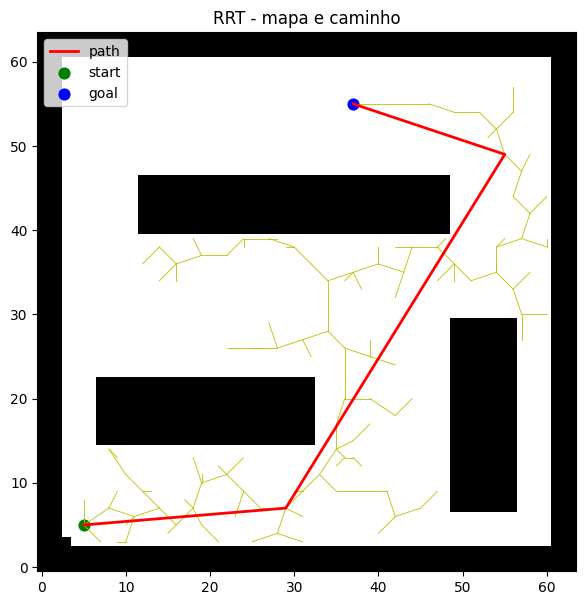

In [33]:
"""
RRT planner para grid 64x64.
Entrada:
 - grid: np.array(rows,cols) com 0=livre, 1=ocupado
 - start: (row, col)
 - goal:  (row, col)
Saída:
 - pos: dict {idx: (x_px, y_px)}  (x_px=coluna, y_px=linha)
 - path: list de índices na ordem do caminho
"""

import numpy as np
import matplotlib.pyplot as plt
import random
import math
import time

# se quiser integrar ao CoppeliaSim (opcional)
try:
    from coppeliasim_zmqremoteapi_client import RemoteAPIClient
    COPPELIA_AVAILABLE = True
except Exception:
    COPPELIA_AVAILABLE = False

class Node:
    def __init__(self, coord, parent=None):
        # coord: (row, col)
        self.coord = coord
        self.parent = parent

def dist(a, b):
    return math.hypot(a[0]-b[0], a[1]-b[1])

def sample_free(rows, cols, goal, goal_sample_rate=0.05):
    """
    Amostragem: com probabilidade goal_sample_rate retorna goal (bias),
    caso contrário retorna amostra aleatória no grid.
    """
    if random.random() < goal_sample_rate:
        return goal
    return (random.randint(0, rows-1), random.randint(0, cols-1))

def nearest(nodes, sample):
    """
    Retorna índice do nó mais próximo na lista `nodes` para a amostra `sample`.
    nodes: lista de Node
    sample: (row,col)
    """
    best_idx = 0
    best_d = float('inf')
    for i, n in enumerate(nodes):
        d = dist(n.coord, sample)
        if d < best_d:
            best_d = d
            best_idx = i
    return best_idx

def steer(from_coord, to_coord, step_size):
    """
    Retorna um novo ponto partindo de `from_coord` na direção de `to_coord`
    com distância máxima step_size (em células). Se a distância é menor que
    step_size, retorna to_coord.
    """
    d = dist(from_coord, to_coord)
    if d <= step_size:
        return to_coord
    else:
        theta = math.atan2(to_coord[0]-from_coord[0], to_coord[1]-from_coord[1])  # note: row ~ y
        # deslocamento em row/col: usamos sin/cos adequadamente
        new_r = from_coord[0] + step_size * math.sin(theta)
        new_c = from_coord[1] + step_size * math.cos(theta)
        # arredondar para inteiro de célula mais próximo
        return (int(round(new_r)), int(round(new_c)))

def collision_free(grid, a, b, step=0.5):
    """
    Verifica colisão entre dois pontos a e b (cada um (row,col)).
    Percorre o segmento em passos e verifica se algum ponto cai em célula ocupada.
    step: resolução de amostragem (em células)
    """
    a_r, a_c = a
    b_r, b_c = b
    length = dist(a, b)
    if length == 0:
        # verificar célula
        r, c = int(round(a_r)), int(round(a_c))
        if 0 <= r < grid.shape[0] and 0 <= c < grid.shape[1]:
            return grid[r, c] == 0
        return False
    n_samples = max(int(math.ceil(length / step)), 1)
    for i in range(n_samples+1):
        t = i / n_samples
        r = a_r + (b_r - a_r) * t
        c = a_c + (b_c - a_c) * t
        ri, ci = int(round(r)), int(round(c))
        if not (0 <= ri < grid.shape[0] and 0 <= ci < grid.shape[1]):
            return False
        if grid[ri, ci] == 1:
            return False
    return True

def reconstruct_path(node):
    path = []
    cur = node
    while cur is not None:
        path.append(cur.coord)
        cur = cur.parent
    return path[::-1]

def rrt_planner(grid, start, goal,
                max_iter=10000,
                step_size=3,
                goal_sample_rate=0.05,
                connect_circle_dist=10,
                visualize=True,
                smoothing_iters=100):
    """
    RRT básico (não RRT*). Retorna pos, path_coords (lista de (row,col)) e nodes.
    """
    rows, cols = grid.shape
    if grid[start[0], start[1]] == 1:
        raise RuntimeError("Start dentro de obstáculo")
    if grid[goal[0], goal[1]] == 1:
        raise RuntimeError("Goal dentro de obstáculo")

    nodes = [Node(start, parent=None)]

    found = False
    goal_node = None
    start_time = time.time()

    for it in range(max_iter):
        sample = sample_free(rows, cols, goal, goal_sample_rate=goal_sample_rate)
        nearest_idx = nearest(nodes, sample)
        nearest_node = nodes[nearest_idx]
        new_coord = steer(nearest_node.coord, sample, step_size)

        # checar limites e colisões
        if not (0 <= new_coord[0] < rows and 0 <= new_coord[1] < cols):
            continue
        if grid[new_coord[0], new_coord[1]] == 1:
            continue
        if not collision_free(grid, nearest_node.coord, new_coord, step=0.5):
            continue

        new_node = Node(new_coord, parent=nearest_node)
        nodes.append(new_node)

        # checar se chegamos no goal (dentro de step_size ou colisão-free para goal)
        if dist(new_coord, goal) <= step_size and collision_free(grid, new_coord, goal, step=0.5):
            goal_node = Node(goal, parent=new_node)
            nodes.append(goal_node)
            found = True
            print(f"✅ RRT: caminho encontrado em iteração {it}, tempo {time.time()-start_time:.2f}s")
            break

    if not found:
        print("⚠️ RRT: não encontrou caminho dentro do número máximo de iterações.")
        return None, None, nodes

    # reconstruir caminho
    path_coords = reconstruct_path(goal_node)

    # smoothing (short-cut): tenta juntar pares distantes se colisão-free
    def shortcut(path_coords, iters=smoothing_iters):
        if len(path_coords) <= 2:
            return path_coords
        for _ in range(iters):
            if len(path_coords) <= 2:
                break
            i = random.randint(0, len(path_coords)-2)
            j = random.randint(i+1, len(path_coords)-1)
            if j == i+1:
                continue
            if collision_free(grid, path_coords[i], path_coords[j], step=0.5):
                # remove os pontos entre i e j
                new_path = path_coords[:i+1] + path_coords[j:]
                path_coords = new_path
        return path_coords

    path_coords = shortcut(path_coords, smoothing_iters)

    # converter para pos (dict idx -> (x_px, y_px)) com x_px = coluna, y_px = linha
    pos = {}
    path = []
    for i, (r, c) in enumerate(path_coords):
        pos[i] = (int(c), int(r))
        path.append(i)

    if visualize:
        plt.figure(figsize=(7,7))
        plt.title("RRT - mapa e caminho")
        plt.imshow(grid, origin='upper', cmap='gray_r')  # obstáculos em preto
        # plot tree
        for n in nodes:
            if n.parent is not None:
                y0, x0 = n.parent.coord
                y1, x1 = n.coord
                plt.plot([x0, x1], [y0, y1], '-y', linewidth=0.6)
        # plot path
        ys = [p[0] for p in path_coords]
        xs = [p[1] for p in path_coords]
        plt.plot(xs, ys, '-r', linewidth=2, label='path')
        plt.scatter([start[1]], [start[0]], c='green', s=60, label='start')
        plt.scatter([goal[1]], [goal[0]], c='blue', s=60, label='goal')
        plt.gca().invert_yaxis()
        plt.legend()
        plt.show()

    return pos, path, nodes

# ============================
# Exemplo de execução (assume que `grid` já existe)
# ============================
# start e goal conforme solicitado


start = (5, 5)
goal  = (55, 37)

# Se você estiver executando este arquivo sozinho, descomente a parte abaixo que cria um exemplo de grid:
# # exemplo: grid de teste (comentado se você fornecer grid real)
# grid = np.zeros((64,64), dtype=int)
# # cria alguns obstáculos de exemplo
# grid[20:30, 20:40] = 1
# grid[10:12, 40:50] = 1
# grid[40:45, 5:20] = 1

# RRT
pos, path, nodes = rrt_planner(grid, start, goal,
                               max_iter=12000,
                               step_size=3,
                               goal_sample_rate=0.05,
                               visualize=True,
                               smoothing_iters=200)


In [36]:
def pixel_to_world(x_px, y_px, img_size=64, world_size=10):
        scale = world_size / img_size
        x_world = (x_px - img_size/2) * scale
        y_world = -(y_px - img_size/2) * scale
        return x_world, y_world


# pos, path, nodes = rrt_planner(grid, start, goal,
#                                max_iter=12000,
#                                step_size=3,
#                                goal_sample_rate=0.05,
#                                visualize=True,
#                                smoothing_iters=200)


pos_world = {node: pixel_to_world(x, y, 64, 10) for node, (x, y) in pos.items()}


L = 0.135
r = 0.040

Mdir = np.array([
        [-r/np.sqrt(3),     0,        r/np.sqrt(3)],
        [r/3,            (-2*r)/3,    r/3],
        [r/(3*L),         r/(3*L),    r/(3*L)]
])




print(pos_world)
client = RemoteAPIClient()
sim = client.require("sim")
sim.setStepping(True)

# posição inicial = primeiro nó do path
start_node = path[0]
start_pos_world = pos_world[start_node]
start_pos_sim = [start_pos_world[0], start_pos_world[1], 0.04]
start_ori_sim = [0, 0, np.deg2rad(90)]


robotname = 'robotino'
robotHandle = sim.getObject('/' + robotname)
# robotHandle = sim.getObjectHandle('/' + robotname)

wheel1 = sim.getObject(f'/{robotname}/wheel0_joint')
wheel2 = sim.getObject(f'/{robotname}/wheel1_joint')
wheel3 = sim.getObject(f'/{robotname}/wheel2_joint')
  

# Parar a simulação se estiver executando
initial_sim_state = sim.getSimulationState()
if initial_sim_state != 0:
    sim.stopSimulation()
    time.sleep(1)

sim.startSimulation()
sim.setObjectPosition(robotHandle, sim.handle_world, start_pos_sim)
sim.setObjectOrientation(robotHandle, sim.handle_world, start_ori_sim)
sim.step()


# Estado inicial
q = np.array([start_pos_sim[0], start_pos_sim[1], start_ori_sim[2]])

print("Iniciando o caminho")

# Caminhos a ser seguidos
waypoints = [pos_world[node] for node in path]
target_index = 0
tolerance = 0.2



# loop principal de seguimento de waypoints
while target_index < len(waypoints):

    print("inciou")
    dt = sim.getSimulationTimeStep()
    target = np.array(waypoints[target_index])
    pos_sim = sim.getObjectPosition(robotHandle, sim.handle_world)
    q[:2] = pos_sim[:2]

    # Erro no referencial do mundo
    erro = target - q[:2]
    dist = np.linalg.norm(erro)

    # Controlador proporcional
    vx_world = 0.7 * erro[0]
    vy_world = 0.7 * erro[1]

    # Limita velocidades
    vx_world = np.clip(vx_world, -0.3, 0.3)
    vy_world = np.clip(vy_world, -0.3, 0.3)

    # Converte velocidade do mundo → corpo (mantendo orientação fixa)
    v_body = Rz(-start_ori_sim[2]) @ np.array([vx_world, vy_world, 0.04])


    # vz_body e descartado por ser 0
    vx_body, vy_body , vz_body = v_body
    w = 0.0  # sem rotação

    # Calcula velocidades das rodas
    qdot = np.array([vx_body, vy_body, w])

    Minv = np.linalg.pinv(Mdir)
    u = Minv @ qdot  # usa cinemática inversa para gerar rodas

    # Envia velocidades
    sim.setJointTargetVelocity(wheel1, u[0])
    sim.setJointTargetVelocity(wheel2, u[1])
    sim.setJointTargetVelocity(wheel3, u[2])

    v = Mdir @ u
    q[0] += v[0] * dt
    q[1] += v[1] * dt
    q[2] += v[2] * dt

    # Avança um passo
    sim.step()

    # Verifica se chegou
    if dist < tolerance:
        print(f"Chegou em {path[target_index]} -> indo para o próximo ponto")
        target_index += 1


print("Caminho concluído! Parando robô...")
for w in [wheel1, wheel2, wheel3]:
    sim.setJointTargetVelocity(w, 0)

posi_final = sim.getObjectPosition(robotHandle, sim.handle_world)
print("Posição final (SIM):", posi_final)
sim.stopSimulation()
print("Program ended.")


{0: (-4.21875, 4.21875), 1: (-0.46875, 3.90625), 2: (3.59375, -2.65625), 3: (0.78125, -3.59375)}
Iniciando o caminho
inciou
Chegou em 0 -> indo para o próximo ponto
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
inciou
in

KeyboardInterrupt: 

In [15]:
# === início das modificações para holonômico sem rotação ===
import numpy as np
import time

def Rz(theta):
    """Matriz de rotação 3x3 para vetores [vx, vy, omega]."""
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([
        [c, -s, 0.0],
        [s,  c, 0.0],
        [0.0, 0.0, 1.0]
    ])

# parâmetros do robô (já no seu código)
L = 0.135
r = 0.040
Mdir = np.array([
    [-r/np.sqrt(3),     0,        r/np.sqrt(3)],
    [r/3,            (-2*r)/3,    r/3],
    [r/(3*L),         r/(3*L),    r/(3*L)]
])

# posição inicial = primeiro nó do path (já presente no seu código)
start_node = path[0]
start_px = pos[start_node]   # (x_px,y_px)
start_pos_xy = pixel_to_world(start_px[0], start_px[1], img_size=64, world_size=10)
start_pos = [start_pos_xy[0], start_pos_xy[1], 0.04]
start_ori = [0, 0, np.deg2rad(90)]
start_angle = start_ori[2]  # manter esta orientação fixa durante todo o trajeto

# ... (setar posição e iniciar simulação como no seu bloco original) ...

# criar lista de waypoints (em metros)
waypoints = [pos_world[node] for node in path]
target_index = 0
tolerance = 0.08  # metros
max_time = 300  # segundos
t0 = time.time()

# obter posição inicial do simulador
try:
    pos_sim = sim.getObjectPosition(robotHandle, sim.handle_world)
    q = np.array([pos_sim[0], pos_sim[1], start_angle])  # z com orientação fixa
except Exception:
    q = np.array([start_pos[0], start_pos[1], start_angle])

# controle (holonômico sem rotação)
Kp_linear = 1.0   # ganho proporcional (ajustável)
max_speed = 0.3   # velocidade linear máxima (m/s)
max_wheel_speed = 20.0  # limite para rodas (rad/s) — ajuste conforme necessário

print("✅ Simulação iniciada; seguindo waypoints (orientação fixa).")

while target_index < len(waypoints):
    if time.time() - t0 > max_time:
        print("⏱️ Tempo máximo de execução atingido; interrompendo.")
        break

    target = np.array(waypoints[target_index])

    # ler posição atual diretamente do simulador (posição no mundo)
    try:
        pos_sim = sim.getObjectPosition(robotHandle, sim.handle_world)
        q[0], q[1] = pos_sim[0], pos_sim[1]
        # mantemos q[2] = start_angle (fixo)
    except Exception:
        pass

    erro = target - q[:2]
    dist_err = np.linalg.norm(erro)

    # Lei de controle linear (direção em world-frame)
    if dist_err > 1e-6:
        speed = Kp_linear * dist_err
        if speed > max_speed:
            speed = max_speed
        v_world = (erro / dist_err) * speed  # vetor [vx, vy] no referencial do mundo
    else:
        v_world = np.array([0.0, 0.0])

    # construir o vetor qdot desejado no referencial do mundo (omega = 0)
    qdot_world = np.array([v_world[0], v_world[1], 0.0])

    # converter para referencial do corpo (body frame) usando orientação fixa
    # v_body = Rz(-theta) @ v_world (3x3 x 3x1)
    v_body = Rz(-start_angle) @ qdot_world

    # calcular velocidades das rodas com pseudo-inversa (mais robusto que inv)
    try:
        u = np.linalg.pinv(Mdir) @ v_body
    except Exception:
        # fallback simples: dividir velocidade entre rodas
        u = np.array([v_world[0], v_world[0], v_world[0]])

    # limitar velocidades das rodas
    u = np.clip(u, -max_wheel_speed, max_wheel_speed)

    # enviar velocidades para as rodas (tratando exceções)
    try:
        sim.setJointTargetVelocity(wheel1, float(u[0]))
        sim.setJointTargetVelocity(wheel2, float(u[1]))
        sim.setJointTargetVelocity(wheel3, float(u[2]))
    except Exception as e:
        print("⚠️ Erro ao setar velocidades:", e)

    # avançar simulação / timestep
    try:
        dt = sim.getSimulationTimeStep()
    except Exception:
        dt = 0.05

    try:
        sim.step()
    except Exception:
        time.sleep(dt)

    # checar alcance do waypoint
    if dist_err < tolerance:
        print(f"✅ Waypoint {target_index} alcançado ({len(waypoints)} total).")
        target_index += 1

# parar as rodas ao final
for w in [wheel1, wheel2, wheel3]:
    try:
        sim.setJointTargetVelocity(w, 0)
    except:
        pass

print("🎯 Execução finalizada (holonômico, sem rotação).")
# pegar posição/orientação final (orientação permanecerá igual a start_angle)
try:
    posf = sim.getObjectPosition(robotHandle, sim.handle_world)
    orif = sim.getObjectOrientation(robotHandle, sim.handle_world)
    print("Posição final:", posf)
    print("Orientação final (deg):", np.rad2deg(orif))
except:
    pass
# === fim das modificações ===


✅ Simulação iniciada; seguindo waypoints (orientação fixa).
⚠️ Erro ao setar velocidades: Operation cannot be accomplished in current state
⚠️ Erro ao setar velocidades: Operation cannot be accomplished in current state
⚠️ Erro ao setar velocidades: Operation cannot be accomplished in current state
⚠️ Erro ao setar velocidades: Operation cannot be accomplished in current state
⚠️ Erro ao setar velocidades: Operation cannot be accomplished in current state
⚠️ Erro ao setar velocidades: Operation cannot be accomplished in current state
⚠️ Erro ao setar velocidades: Operation cannot be accomplished in current state
⚠️ Erro ao setar velocidades: Operation cannot be accomplished in current state
⚠️ Erro ao setar velocidades: Operation cannot be accomplished in current state
⚠️ Erro ao setar velocidades: Operation cannot be accomplished in current state
⚠️ Erro ao setar velocidades: Operation cannot be accomplished in current state
⚠️ Erro ao setar velocidades: Operation cannot be accomplish

KeyboardInterrupt: 